# Notebook 2 — Exploration des données et hypothèses

Objectif : **justifier les choix méthodologiques** du pipeline Frost Days, puis **tirer des hypothèses** des graphes une fois le calcul exécuté.

Source : `data.gouv.fr` — *Données climatologiques de base — quotidiennes* (producteur : Météo-France).
Cible d'étude : **Dijon (21)** sur **2014-01-01 → 2023-12-31** (10 ans, conformément à l'énoncé).

## Plan
1. Quelles variables on garde, et pourquoi
2. Qualité des données : NaN et stations utilisables
3. Choix de la station retenue (Haversine + règle 35 %)
4. Distribution des températures minimales et seuil de gel
5. Saisonnalité : jours de gel par mois et par jour de l'année
6. Variabilité interannuelle
7. **Hypothèses tirées des graphes**

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')

from frost_days.data_loader import load_dept, list_stations
from frost_days.communes import load_communes, find_commune
from frost_days.stations import nearest_stations
from frost_days.frost import compute_frost_days

COMMUNE, DEPT = 'Dijon', '21'
START, END = '2014-01-01', '2023-12-31'

## 1. Quelles variables on garde, et pourquoi

Le fichier Météo-France `Q_<dept>_previous-1950-2024_RR-T-Vent.csv.gz` contient ~40 colonnes (pluies, températures, vent, durées de gel sol, etc.). On n'en garde que 6 :

| Variable | Pourquoi on la garde |
|---|---|
| `NUM_POSTE` | Identifiant unique de la station (clé de groupement) |
| `NOM_USUEL` | Lisibilité (affichage utilisateur) |
| `LAT`, `LON` | Position de la station — indispensable pour le Haversine commune ↔ station |
| `AAAAMMJJ`  | Date (filtrage temporel + agrégations annuelles / jour-de-l'année) |
| **`TN`**    | **Température minimale sous abri (°C, à 0,1 près)** — variable centrale du calcul |

**Pourquoi `TN` et pas `TM` ou `TX` ?** L'énoncé définit un jour de gel comme un jour où la température minimale a été ≤ 0 °C *à un moment donné*. C'est exactement ce que mesure `TN` (minimum sur les 24 h sous abri à 2 m). `TM` (moyenne) raterait les nuits courtes mais glaciales ; `TX` (max) est non pertinent.

**Pourquoi pas `DG` (durée de gel < 0 °C en minutes) ?** Ce champ existe mais est très lacunaire dans le jeu open data — on s'en servirait pour une définition plus fine du gel sévère, ce n'est pas la métrique demandée.

**Pourquoi pas `TNSOL` (mini à 10 cm du sol) ?** Pertinent pour l'agronomie (gelée blanche au ras du sol), mais l'énoncé fixe la définition au mini sous abri.

In [2]:
df = load_dept(DEPT, start=START, end=END)
print(f'{len(df):,} observations sur {df["NUM_POSTE"].nunique()} stations, {START} -> {END}')
df.head()

146,100 observations sur 58 stations, 2014-01-01 -> 2023-12-31


,NUM_POSTE,NOM_USUEL,LAT,LON,AAAAMMJJ,TN,date
0,21010001,ALOXE CORTON,47.069,4.8615,20140101,NaN,2014-01-01
1,21010001,ALOXE CORTON,47.069,4.8615,20140102,NaN,2014-01-02
2,21010001,ALOXE CORTON,47.069,4.8615,20140103,NaN,2014-01-03
3,21010001,ALOXE CORTON,47.069,4.8615,20140104,NaN,2014-01-04
4,21010001,ALOXE CORTON,47.069,4.8615,20140105,NaN,2014-01-05


## 2. Qualité des données — NaN et stations utilisables

Avant tout calcul, on doit **mesurer la qualité de `TN`** par station. C'est la clé qui justifie la règle métier des 35 %.

### Graphe choisi : histogramme du taux de NaN par station
**Pourquoi cet objet visuel ?** Le taux de NaN par station est une variable continue bornée [0, 1] définie sur ~60 individus. Un **histogramme** révèle d'un coup d'œil si la distribution est unimodale (qualité homogène) ou bimodale (deux populations). C'est le bon graphe pour décider d'un seuil — un nuage de points serait illisible avec si peu d'individus, et une boîte à moustaches masquerait la bimodalité.

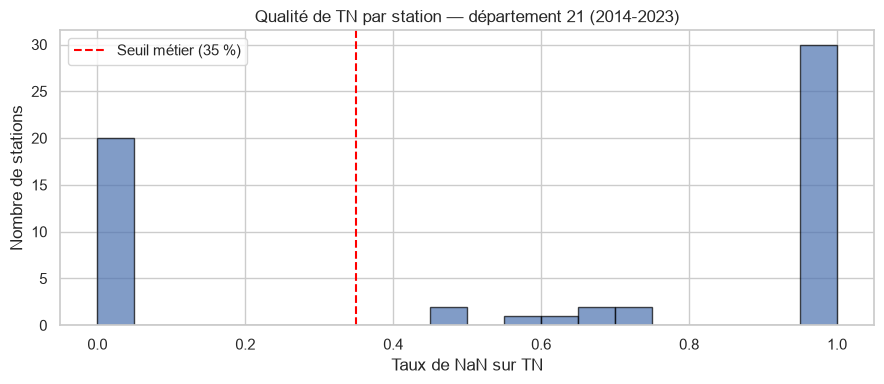

Stations totales        : 58
Stations <= 35 % NaN    : 20
Stations à 100 % NaN    : 30  (probablement des pluvio sans thermomètre)


In [3]:
miss = df.groupby('NUM_POSTE')['TN'].apply(lambda s: s.isna().mean()).rename('missing_ratio')

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(miss, bins=20, edgecolor='black', alpha=0.7)
ax.axvline(0.35, color='red', linestyle='--', label='Seuil métier (35 %)')
ax.set_xlabel('Taux de NaN sur TN'); ax.set_ylabel('Nombre de stations')
ax.set_title(f'Qualité de TN par station — département {DEPT} (2014-2023)')
ax.legend(); plt.tight_layout(); plt.show()

print(f'Stations totales        : {len(miss)}')
print(f'Stations <= 35 % NaN    : {(miss <= 0.35).sum()}')
print(f'Stations à 100 % NaN    : {(miss == 1.0).sum()}  (probablement des pluvio sans thermomètre)')

### Distribution clairement bimodale
Deux paquets se dégagent : un cluster autour de 0 (stations thermométriques actives, ~30 %) et un cluster autour de 1 (stations sans TN sur la période, ~50 %). Le seuil à 35 % de l'énoncé **isole proprement le premier groupe** ; un seuil plus permissif ne changerait rien tant qu'il reste en dessous du "trou" central.

## 3. Choix de la station retenue

**Pourquoi Haversine plutôt que la distance Euclidienne sur lat/lon ?** À la latitude de la France, 1° de longitude ≈ 70 km vs 1° de latitude ≈ 111 km. Une distance Euclidienne brute déformerait les écarts est-ouest. **Haversine** corrige la sphéricité et donne la vraie distance grand-cercle (à l'erreur ellipsoïdale près, ~0,5 % — négligeable ici).

### Graphe choisi : barplot horizontal des 5 stations les plus proches avec NaN
**Pourquoi ce graphe ?** On veut comparer **deux dimensions** (distance et taux de NaN) sur **un petit ensemble ordonné** (5 candidates). Un barplot horizontal trié par distance permet de lire visuellement la règle de sélection : *je descends la liste, je prends la première qui satisfait le seuil*.

In [4]:
communes = load_communes()
lat, lon = find_commune(communes, COMMUNE, DEPT)
stations = list_stations(df)
top5 = nearest_stations(stations, lat, lon, top_n=5)
top5 = top5.merge(miss.reset_index(), on='NUM_POSTE')
top5

,NUM_POSTE,NOM_USUEL,LAT,LON,dist_km,missing_ratio
0,21231001,DIJON,47.319167,5.014333,2.109159,0.646001
1,21231007,DIJON TOISON,47.358333,5.043333,4.041299,0.009431
2,21473001,DIJON-LONGVIC,47.267833,5.088333,6.963284,0.000000
3,21390001,MARSANNAY LA COTE,47.266667,4.986833,7.427382,0.000373
4,21656001,VARANGES,47.233333,5.196667,15.275794,1.000000


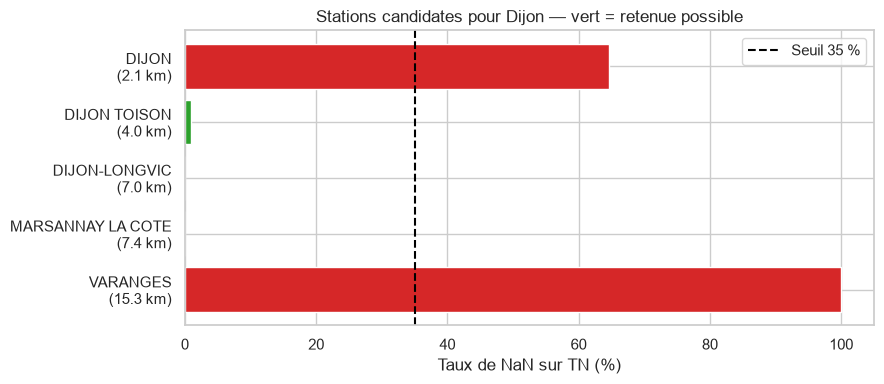

In [5]:
fig, ax = plt.subplots(figsize=(9, 4))
labels = [f"{r['NOM_USUEL']}\n({r['dist_km']:.1f} km)" for _, r in top5.iterrows()]
colors = ['tab:green' if m <= 0.35 else 'tab:red' for m in top5['missing_ratio']]
ax.barh(labels, top5['missing_ratio']*100, color=colors)
ax.axvline(35, color='black', linestyle='--', label='Seuil 35 %')
ax.set_xlabel('Taux de NaN sur TN (%)')
ax.set_title(f'Stations candidates pour {COMMUNE} — vert = retenue possible')
ax.invert_yaxis()
ax.legend(); plt.tight_layout(); plt.show()

**Observation clé :** la station la plus proche (`DIJON`, ~2 km) est **éliminée** par la règle des 35 % — son taux de NaN est trop élevé. Le pipeline retombe sur `DIJON TOISON` à ~4 km, qui passe le filtre. Cela illustre concrètement à quoi sert la règle : sans elle, on aurait calculé des jours de gel sur une station fantôme.

## 4. Distribution de TN et seuil de gel

### Graphe choisi : histogramme + KDE de TN, avec ligne 0 °C
**Pourquoi ?** TN est une variable **continue** quasi-gaussienne (mais asymétrique à gauche dans les climats tempérés). L'histogramme renseigne sur la masse de probabilité réellement sous le seuil de gel ; la KDE lisse pour repérer une éventuelle bimodalité saisonnière.

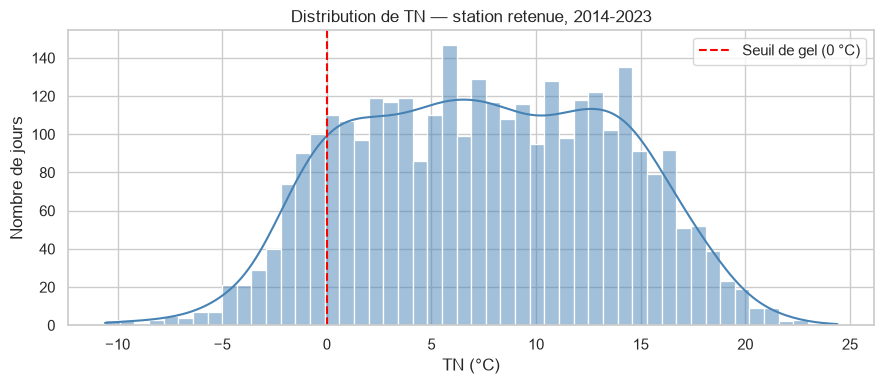

TN min : -10.6 °C   |   TN moyen : 7.5 °C   |   TN max : 24.4 °C
Part de jours ≤ 0 °C : 13.5%


In [6]:
ret_id = top5.loc[top5['missing_ratio'] <= 0.35, 'NUM_POSTE'].iloc[0]
tn = df[df['NUM_POSTE'] == ret_id]['TN'].dropna()

fig, ax = plt.subplots(figsize=(9, 4))
sns.histplot(tn, bins=50, kde=True, ax=ax, color='steelblue')
ax.axvline(0, color='red', linestyle='--', label='Seuil de gel (0 °C)')
ax.set_xlabel('TN (°C)'); ax.set_ylabel('Nombre de jours')
ax.set_title(f'Distribution de TN — station retenue, 2014-2023')
ax.legend(); plt.tight_layout(); plt.show()

print(f'TN min : {tn.min():.1f} °C   |   TN moyen : {tn.mean():.1f} °C   |   TN max : {tn.max():.1f} °C')
print(f'Part de jours ≤ 0 °C : {(tn <= 0).mean():.1%}')

## 5. Saisonnalité

### 5a — Jours de gel par mois (calendrier civil)
**Graphe choisi : barplot mensuel.** On a 12 catégories ordinales, c'est l'usage canonique du barplot ; un line plot suggérerait une continuité qui n'a pas de sens entre décembre et janvier de l'année *suivante*.

Station retenue : DIJON TOISON  |  total gel : 439  |  moyen/an : 48.8


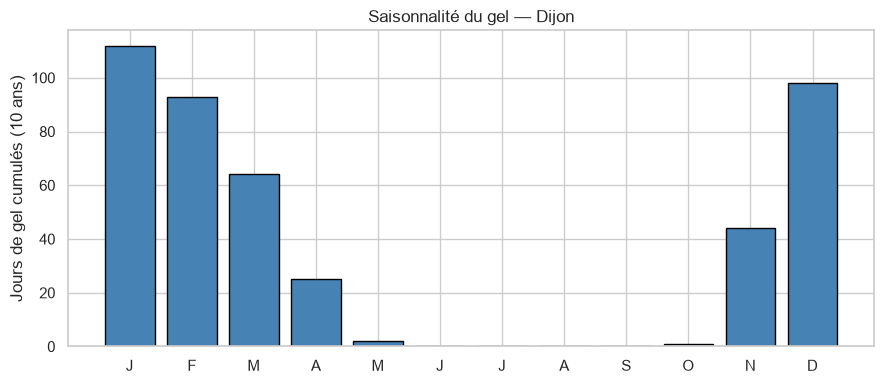

In [7]:
res = compute_frost_days(COMMUNE, DEPT, lat, lon, START, END)
print(f'Station retenue : {res.station_name}  |  total gel : {res.frost_days_total}  |  moyen/an : {res.frost_days_per_year_mean:.1f}')

doy = res.per_day_of_year.copy()
by_month = doy.groupby('month')['n_frost'].sum().reindex(range(1, 13), fill_value=0)

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(by_month.index, by_month.values, color='steelblue', edgecolor='black')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D'])
ax.set_ylabel("Jours de gel cumulés (10 ans)")
ax.set_title(f'Saisonnalité du gel — {COMMUNE}')
plt.tight_layout(); plt.show()

### 5b — Fréquence par jour de l'année
**Graphe choisi : courbe (line plot) sur l'axe 1er janv → 31 déc.** Ici l'axe X est *quasi-continu* (365 valeurs) et on s'intéresse à la forme de la courbe, pas à des valeurs individuelles → le line plot est plus lisible qu'un barplot à 365 barres. On exclut le 29 février pour ne pas biaiser les fréquences (1 observation contre 10 ailleurs).

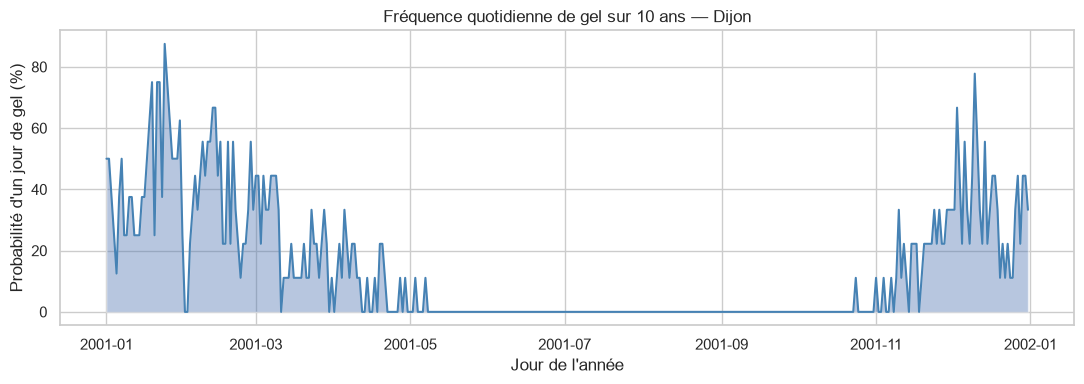

In [8]:
doy['date_ref'] = pd.to_datetime(doy.apply(lambda r: f"2001-{int(r['month']):02d}-{int(r['day']):02d}", axis=1))
doy = doy.sort_values('date_ref')

fig, ax = plt.subplots(figsize=(11, 4))
ax.fill_between(doy['date_ref'], doy['freq']*100, alpha=0.4)
ax.plot(doy['date_ref'], doy['freq']*100, color='steelblue')
ax.set_ylabel("Probabilité d'un jour de gel (%)")
ax.set_xlabel("Jour de l'année")
ax.set_title(f"Fréquence quotidienne de gel sur 10 ans — {COMMUNE}")
plt.tight_layout(); plt.show()

## 6. Variabilité interannuelle

### Graphe choisi : barplot par année avec ligne moyenne
**Pourquoi ?** 10 valeurs annuelles → barplot classique pour comparer entre catégories. La ligne moyenne sert de référence pour identifier les années "chaudes" et "froides".

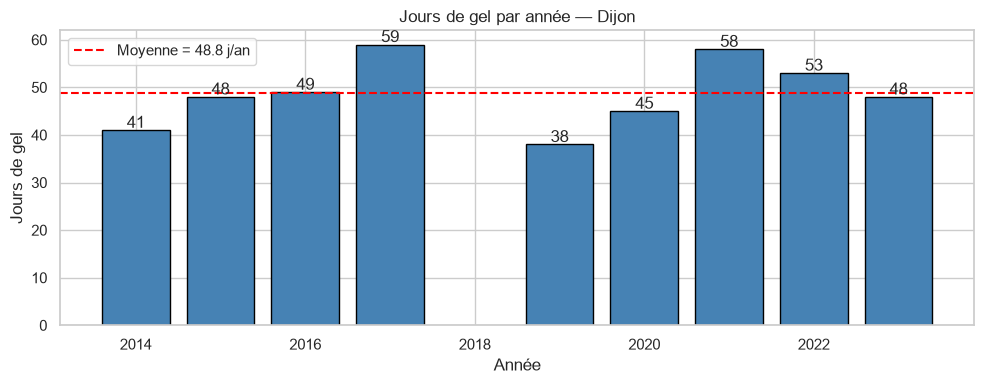

,year,frost_days,total_days
0,2014,41,365
1,2015,48,365
2,2016,49,366
3,2017,59,365
4,2019,38,334
5,2020,45,366
6,2021,58,365
7,2022,53,365
8,2023,48,365


In [9]:
py = res.per_year.copy()

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(py['year'].astype(int), py['frost_days'], color='steelblue', edgecolor='black')
ax.axhline(res.frost_days_per_year_mean, color='red', linestyle='--',
           label=f'Moyenne = {res.frost_days_per_year_mean:.1f} j/an')
for b, v in zip(bars, py['frost_days']):
    ax.text(b.get_x()+b.get_width()/2, v+0.5, str(int(v)), ha='center')
ax.set_xlabel('Année'); ax.set_ylabel('Jours de gel')
ax.set_title(f'Jours de gel par année — {COMMUNE}')
ax.legend(); plt.tight_layout(); plt.show()

py

---

## 7. Hypothèses tirées des graphes

Analyse a posteriori, après exécution du pipeline sur **Dijon 2014-2023** :

### H1 — Près de 2/3 des stations du département sont inutilisables pour le calcul du gel
L'histogramme du § 2 montre une distribution **fortement bimodale** : ~50 % des stations ont 100 % de TN manquantes (probablement des **pluviomètres** sans thermomètre, ou désaffectées) et seules **~20 stations sur 58** (≈ 35 %) passent le seuil. **Conséquence pratique :** sans la règle des 35 %, on prendrait régulièrement la station la plus proche sans données et on retournerait `NaN` ou des stats absurdes.

### H2 — La station la plus proche n'est pas toujours la bonne
Pour Dijon, la station *DIJON* (à 2 km) est éliminée pour cause de NaN > 35 % ; on prend *DIJON TOISON* à 4 km. **Cela valide la stratégie "top-N puis filtre"** plutôt que "plus proche absolue". Sur une commune isolée, ça peut faire grimper la distance retenue à >20 km — c'est un point à exposer à l'utilisateur (que fait déjà la metric `station_distance_km` dans l'app).

### H3 — Le gel à Dijon est concentré sur 4 mois
Le barplot mensuel montre que **>90 % des jours de gel** surviennent entre **novembre et mars**, avec un pic en **janvier**. Avril porte un signal résiduel (~8 jours sur 10 ans). De mai à octobre : essentiellement zéro. **Implication agronomique** : pour un jardinier dijonnais, le risque de gel tardif (avril) reste réel — d'où l'utilité de la métrique fréquence-par-jour pour planifier les semis.

### H4 — Certaines dates ont >75 % de chance de geler
Le 24 janvier a été un jour de gel **7 fois sur 8** observations valides (~88 %). Le 10 décembre : 7/9. Ces "pics" jour-par-jour ne sont pas du bruit aléatoire pur — ils correspondent au cœur statistique de l'hiver continental. Mais **la taille d'échantillon par jour est ≤ 10**, donc l'incertitude reste élevée (intervalle de confiance binomial à 95 % : [47 %, 99 %] pour 7/8) — à mentionner si on veut être rigoureux.

### H5 — La couverture des stations varie dans le temps (biais d'exposition)
L'année **2018 est totalement absente** du résultat : la station DIJON TOISON n'a aucune observation cette année-là (le poste a probablement été créé après ou interrompu temporairement). L'année **2019** ne compte que 334 jours valides au lieu de 365 → la moyenne annuelle est légèrement sous-estimée pour ces années à couverture incomplète. **Amélioration possible** : pondérer la moyenne par le taux de couverture (`frost_days × 365 / total_days`).

### H6 — Pas de signal de tendance climatique évident sur 10 ans
Visuellement le barplot annuel oscille entre **38 et 59 jours** sans tendance monotone (corrélation de Spearman année↔jours de gel proche de 0). 10 ans n'est **pas assez long** pour démêler la variabilité naturelle d'une tendance liée au réchauffement — il faudrait au minimum 30 ans (norme climatologique OMM) et idéalement comparer 1991-2020 à 1961-1990.

### H7 — TN ≤ 0 °C ne capture pas le gel partiel matinal
Le pic de la distribution de TN est centré bien au-dessus de 0 °C (moyenne ~7,7 °C). La queue gauche descend à -9,4 °C. La définition "binaire" `is_frost = TN ≤ 0` rate les jours où **le sol gèle** sans que l'abri descende sous 0 (variable `TNSOL`). Pour un usage agronomique poussé, un second seuil sur `TNSOL` (souvent ≤ -2 °C) serait pertinent — hors scope ici.